In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from torch.utils.data import DataLoader,TensorDataset

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("train.csv")

In [4]:
len(df)

750000

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [6]:
df.head(2)

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0


In [7]:
df.drop("id",axis=1,inplace=True)

In [8]:
df["Sex"] = pd.get_dummies(df["Sex"],drop_first=True,dtype="int")

In [9]:
df.head(2)

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,36,189.0,82.0,26.0,101.0,41.0,150.0
1,0,64,163.0,60.0,8.0,85.0,39.7,34.0


In [10]:
x = df.drop("Calories",axis=1).values
y = df["Calories"].values

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [13]:
scaler_2 = StandardScaler()
y_train = scaler_2.fit_transform(y_train.reshape(-1,1))
y_test = scaler_2.transform(y_test.reshape(-1,1))

In [14]:
x_train = torch.tensor(x_train,dtype=torch.float32)
x_test = torch.tensor(x_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

In [15]:
train_dataset = TensorDataset(
    x_train,
    y_train
)

test_dataset = TensorDataset(
    x_test,
    y_test
)

In [16]:
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=100
)

test_loader = DataLoader(
    test_dataset,
    shuffle=True,
    batch_size=100
)

In [18]:
class ResidualBlock(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.fc1 = nn.Linear(dim,dim)
        self.ln1 = nn.LayerNorm(dim)
        
        self.fc2 = nn.Linear(dim,dim)
        self.ln2 = nn.LayerNorm(dim)

        self.relu = nn.ReLU()

    def forward(self,x):
        identity = x
        out = self.fc1(x)
        out = self.ln1(out)
        out = self.relu(out)

        out = self.fc2(out)
        out = self.ln2(out)

        out = out + identity

        out = self.relu(out)

        return out

In [19]:
class MyModel(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.LayerNorm(128),
            nn.ReLU()
        )

        self.re1 = ResidualBlock(128)
        self.re2 = ResidualBlock(128)

        self.output = nn.Linear(128,1)
    
    def forward(self,x):
        x = self.input_layer(x)

        x = self.re1(x)
        x = self.re2(x)

        x = self.output(x)

        return x

In [21]:
model = MyModel(7)

In [22]:
for name,param in model.named_parameters():
    print(name,param.shape)

input_layer.0.weight torch.Size([128, 7])
input_layer.0.bias torch.Size([128])
input_layer.1.weight torch.Size([128])
input_layer.1.bias torch.Size([128])
re1.fc1.weight torch.Size([128, 128])
re1.fc1.bias torch.Size([128])
re1.ln1.weight torch.Size([128])
re1.ln1.bias torch.Size([128])
re1.fc2.weight torch.Size([128, 128])
re1.fc2.bias torch.Size([128])
re1.ln2.weight torch.Size([128])
re1.ln2.bias torch.Size([128])
re2.fc1.weight torch.Size([128, 128])
re2.fc1.bias torch.Size([128])
re2.ln1.weight torch.Size([128])
re2.ln1.bias torch.Size([128])
re2.fc2.weight torch.Size([128, 128])
re2.fc2.bias torch.Size([128])
re2.ln2.weight torch.Size([128])
re2.ln2.bias torch.Size([128])
output.weight torch.Size([1, 128])
output.bias torch.Size([1])


In [23]:
loss_function = nn.MSELoss()

optimizer_function = torch.optim.AdamW(model.parameters(),
                                       lr=0.001,
                                       weight_decay=0.01)

In [ ]:
train_loss_hist = []
test_loss_hist = []

epochs = 50
process_bar = tqdm(range(epochs),colour="blue")

for epoch in process_bar:
    model.train()
    total_train_loss = 0
    for batch_train_x,batch_train_y in train_loader:
        optimizer_function.zero_grad()
        train_prediction = model(batch_train_x)
        loss = loss_function(train_prediction,batch_train_y)
        loss.backward()
        #gradient clipping
        nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        optimizer_function.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss   / len(train_loader)

    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch_test_x,batch_test_y in test_loader:
            test_prediction = model(batch_test_x)
            test_loss = loss_function(test_prediction,batch_test_y)
            total_test_loss += test_loss.item()
    avg_test_loss = total_test_loss / len(test_loader)
    
    train_loss_hist.append(avg_train_loss)
    test_loss_hist.append(avg_test_loss)

    torch.save({
      "Epochs":epoch,
      "Test Loss":avg_test_loss,
      "Train Loss":avg_train_loss,
      "Optimizer":optimizer_function.state_dict(),
      "Model":model.state_dict()  
    },f"residual_model/checkpoint_{epoch+1}.pth")

    process_bar.set_postfix({
        "Epoch":epoch+1,
        "Train Loss":f"{avg_train_loss:.4f}",
        "Test Loss":f"{avg_test_loss:.4f}"
    })


100%|██████████| 50/50 [22:11<00:00, 26.63s/it, Epoch=50, Train Loss=0.0034, Test Loss=0.0034]


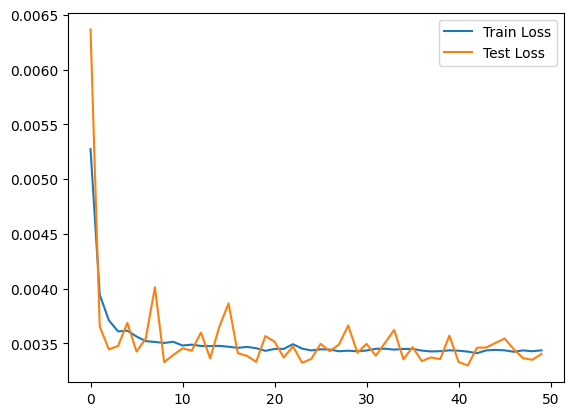

In [25]:
plt.plot(train_loss_hist,label="Train Loss")
plt.plot(test_loss_hist,label="Test Loss")
plt.legend()